# FEMM (Finite Element Method Magnetics)

In [16]:
import torch
import numpy as np
import time
import meshio
import gmsh

import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.colors as colors

import scipy.sparse as sp
import scipy.sparse.linalg as spla

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Выбрано: {device}")

Выбрано: cuda


In [17]:
def solve_fem(refineK):

    #генерация сетки
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.open("dipole2d.geo")
    gmsh.model.mesh.generate(2)
    
    for _ in range(refineK):
        gmsh.model.mesh.refine()
        
    temp_mesh_file = f"dipole2d_refined_{refineK}.msh"
    gmsh.write(temp_mesh_file)
    gmsh.finalize()

    #чтение сетки
    mesh = meshio.read(temp_mesh_file)

    X_y = mesh.points[:, :2]

    all_triangles = []
    all_triangle_tags = []
    all_lines = []
    all_line_tags = []

    physical_data = mesh.cell_data.get("gmsh:physical", [])

    for i, cell_block in enumerate(mesh.cells):

        if cell_block.type == "triangle":
            all_triangles.append(cell_block.data)
            all_triangle_tags.append(physical_data[i])

        elif cell_block.type == "line":
            all_lines.append(cell_block.data)
            all_line_tags.append(physical_data[i])

    triangles = np.concatenate(all_triangles, axis=0)
    triangle_tags = np.concatenate(all_triangle_tags, axis=0)
    lines = np.concatenate(all_lines, axis=0)
    line_tags = np.concatenate(all_line_tags, axis=0)

    #физические свойства материалов
    mu0 = 4 * np.pi * 1e-7
    mu_steel = 1000.0 * mu0

    mu_elem_np = np.ones(len(triangles)) * mu0
    mu_elem_np[triangle_tags == 22] = mu_steel

    J_elem_np = np.zeros(len(triangles))
    J_elem_np[triangle_tags == 23] = 1.0
    J_elem_np[triangle_tags == 24] = -1.0

    #тензоры
    nodes = torch.tensor(X_y, dtype=torch.float32, device=device)
    elements = torch.tensor(triangles, dtype=torch.long, device=device)
    mu_elem = torch.tensor(mu_elem_np, dtype=torch.float32, device=device)
    J_elem = torch.tensor(J_elem_np, dtype=torch.float32, device=device)

    num_nodes = nodes.shape[0]

    #локальные матрицы жесткости
    p = nodes[elements]
    p1, p2, p3 = p[:, 0], p[:, 1], p[:, 2]
        
    area = 0.5 * torch.abs((p2[:, 0] - p1[:, 0]) * (p3[:, 1] - p1[:, 1]) - 
                           (p3[:, 0] - p1[:, 0]) * (p2[:, 1] - p1[:, 1]))
        
    alpha_1 = torch.stack([p2[:, 1] - p3[:, 1], p3[:, 1] - p1[:, 1], p1[:, 1] - p2[:, 1]], dim=1)
    alpha_2 = torch.stack([p3[:, 0] - p2[:, 0], p1[:, 0] - p3[:, 0], p2[:, 0] - p1[:, 0]], dim=1)
         
    G_local = (1.0 / (4.0 * area * mu_elem))[:, None, None] * (alpha_1[:, :, None] * alpha_1[:, None, :] + 
                                                             alpha_2[:, :, None] * alpha_2[:, None, :])
        
    F_local = (J_elem * area / 3.0)[:, None].expand(-1, 3)

    #сборка глобальной разреженной матрицы
    rows_np = elements[:, :, None].expand(-1, 3, 3).reshape(-1).cpu().numpy()
    cols_np = elements[:, None, :].expand(-1, 3, 3).reshape(-1).cpu().numpy()
    vals_np = G_local.reshape(-1).cpu().numpy()

    G_sparse = sp.coo_matrix((vals_np, (rows_np, cols_np)), shape=(num_nodes, num_nodes)).tolil()

    F = torch.zeros(num_nodes, device=device)
    F.index_add_(0, elements.reshape(-1), F_local.reshape(-1))
    F_np = F.cpu().numpy()

    #Дирихле (tag 27)
    dirichlet_lines = lines[line_tags == 27]
    dirichlet_idx = np.unique(dirichlet_lines)

    G_sparse[dirichlet_idx, :] = 0.0
    G_sparse[dirichlet_idx, dirichlet_idx] = 1.0
    G_sparse = G_sparse.tocsr()

    F_np[dirichlet_idx] = 0.0

    #решение СЛАУ
    u_fem_np = spla.spsolve(G_sparse, F_np)
    
    return X_y, triangles, u_fem_np, triangle_tags

In [18]:
start_time = time.time()

print("Running the calculation on a sparse grid (refineK=2)...")
X_c, tri_c, u_c, tags_c = solve_fem(refineK=2)

print("Running the calculation on a dense grid (refineK=3)...")
X_f, tri_f, u_f, _ = solve_fem(refineK=3)

print(f"Calculations completed in {time.time() - start_time:.2f} сек.")

Running the calculation on a sparse grid (refineK=2)...

Running the calculation on a dense grid (refineK=3)...

Calculations completed in 1.02 сек.


<h3> Mesh Visualization </h3>


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


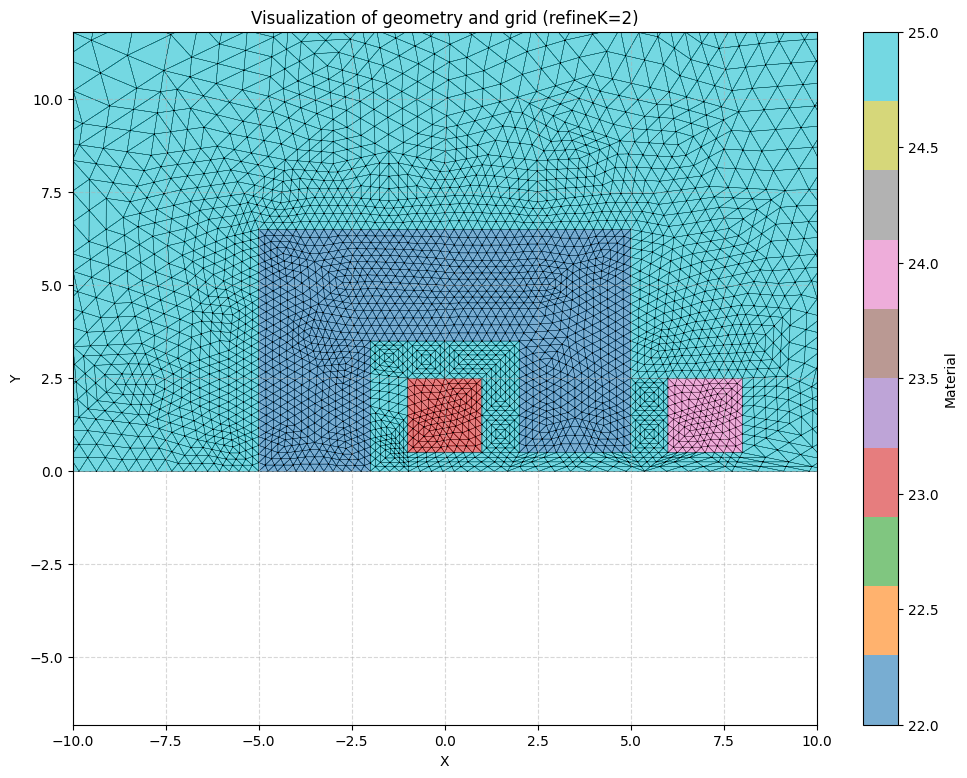

In [19]:
triang = tri.Triangulation(X_c[:, 0], X_c[:, 1], tri_c)

plt.figure(figsize=(12, 9))

tpc = plt.tripcolor(triang, facecolors=tags_c, cmap='tab10', alpha=0.6)

plt.triplot(triang, color='black', lw=0.3)
plt.colorbar(tpc, label="Material")

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Visualization of geometry and grid (refineK=2)")
plt.axis('equal') 

plt.xlim(-10, 10)
plt.ylim(-5, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Magnetic field distribution

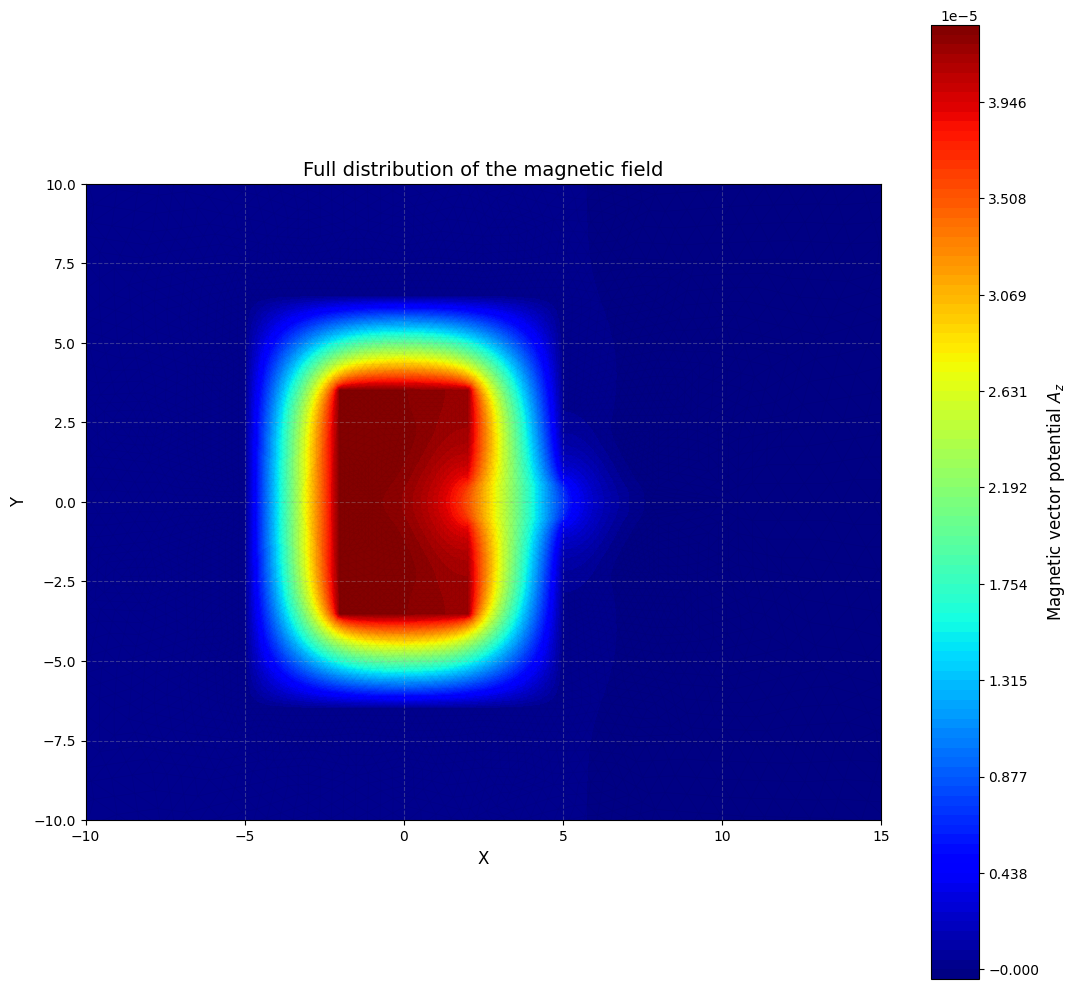

In [20]:
#объект триангуляции matplotlib

triangulation_top = tri.Triangulation(X_c[:, 0], X_c[:, 1], tri_c)
triangulation_bottom = tri.Triangulation(X_c[:, 0], -X_c[:, 1], tri_c)

plt.figure(figsize=(11, 10))
ax = plt.gca()
ax.set_aspect('equal')

vmin = u_c.min()
vmax = u_c.max()
levels = np.linspace(vmin, vmax, 100)

contour_top = ax.tricontourf(triangulation_top, u_c, levels=levels, cmap='jet')
contour_bottom = ax.tricontourf(triangulation_bottom, u_c, levels=levels, cmap='jet')

ax.triplot(triangulation_top, color='black', alpha=0.05, linewidth=0.5)
ax.triplot(triangulation_bottom, color='black', alpha=0.05, linewidth=0.5)

cbar = plt.colorbar(contour_top)
cbar.set_label('Magnetic vector potential $A_z$', fontsize=12)

ax.set_xlim(-10, 15)
ax.set_ylim(-10, 10)

# ax.set_xlim(-55, 55)
# ax.set_ylim(-55, 55)

plt.title('Full distribution of the magnetic field', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

### Transition from the found scalar potential $A_z$ to the magnetic induction vector $B$

In [21]:
#интерполяторы (значение потенциала в произвольной точке)
interp_top = tri.LinearTriInterpolator(triangulation_top, u_c)
interp_bottom = tri.LinearTriInterpolator(triangulation_bottom, u_c)

X, Y = np.meshgrid(np.linspace(-7, 9, 40), np.linspace(-8, 8, 40))

U = np.zeros_like(X)
V = np.zeros_like(Y)

#отбор внутренних точек
mask_top = (Y >= 0) & (triangulation_top.get_trifinder()(X, Y) != -1)
mask_bottom = (Y < 0) & (triangulation_bottom.get_trifinder()(X, Y) != -1)

### Calculation of magnetic induction components $B$

In [22]:
dAdx_t, dAdy_t = interp_top.gradient(X[mask_top], Y[mask_top])
U[mask_top] = dAdy_t
V[mask_top] = -dAdx_t

dAdx_b, dAdy_b = interp_bottom.gradient(X[mask_bottom], Y[mask_bottom])
U[mask_bottom] = dAdy_b
V[mask_bottom] = -dAdx_b

B_norm_grid = np.sqrt(U**2 + V**2)
mask_total = mask_top | mask_bottom

In [23]:

dAdx_n, dAdy_n = interp_top.gradient(X_c[:, 0], X_c[:, 1])
B_norm_nodes = np.sqrt(dAdy_n**2 + dAdx_n**2)

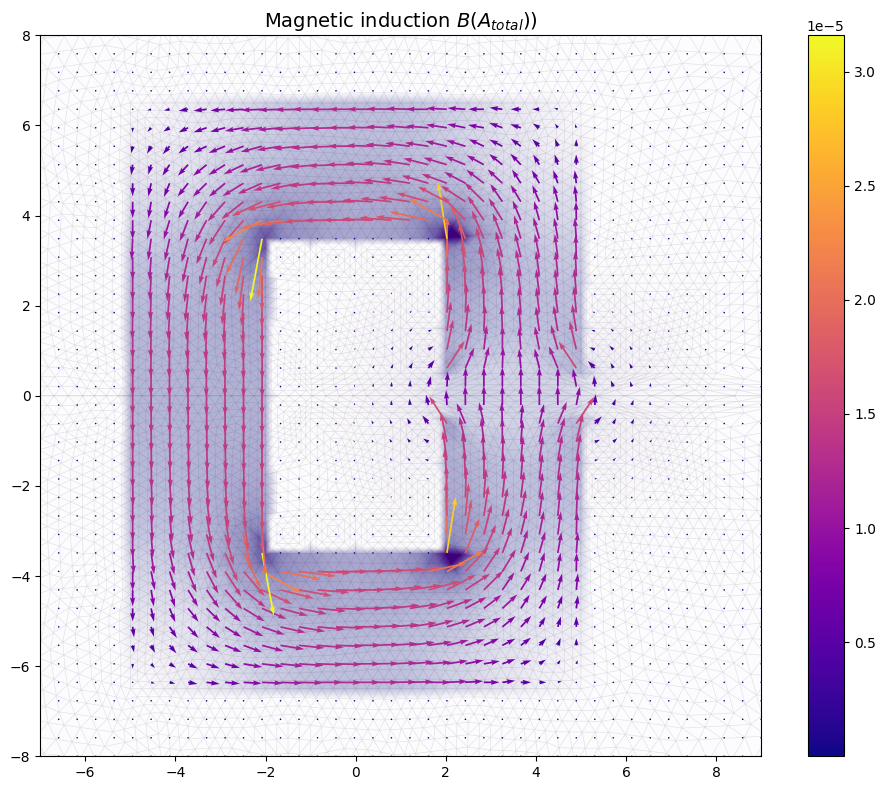

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_aspect('equal')
ax.set_xlim(-7, 9)
ax.set_ylim(-8, 8)
ax.set_title('Magnetic induction $B(A_{total})$)', fontsize=14)

ax.tripcolor(triangulation_top, B_norm_nodes, shading='gouraud', cmap='Purples')
ax.tripcolor(triangulation_bottom, B_norm_nodes, shading='gouraud', cmap='Purples')

ax.triplot(triangulation_top, color='black', alpha=0.1, linewidth=0.5)
ax.triplot(triangulation_bottom, color='black', alpha=0.1, linewidth=0.5)

bar = ax.quiver(X[mask_total], Y[mask_total], U[mask_total], V[mask_total], B_norm_grid[mask_total], cmap='plasma')

fig.colorbar(bar, ax=ax)
plt.tight_layout()
plt.show()

<h3> Relative error in potential <i>A<i> </h3>

$\text{Error}_A = \frac{|A - A_{\mathit{dbl}}|}{\max |A_{\mathit{dbl}}|}$

In [ ]:
triang_c_top = tri.Triangulation(X_c[:, 0], X_c[:, 1], tri_c)
triang_c_bottom = tri.Triangulation(X_c[:, 0], -X_c[:, 1], tri_c)

triang_f_top = tri.Triangulation(X_f[:, 0], X_f[:, 1], tri_f)

interp_A_c = tri.LinearTriInterpolator(triang_c_top, u_c)
interp_A_f = tri.LinearTriInterpolator(triang_f_top, u_f)

u_f_at_c_nodes = interp_A_f(X_c[:, 0], X_c[:, 1])

max_A_norm = np.max(np.abs(u_f_at_c_nodes))

error_A = np.abs(u_c - u_f_at_c_nodes) / max_A_norm

<h3> Relative error by induction <i>B<i> </h3>

$\text{Error}_B = \frac{\sqrt{(B_{x} - B_{x,\mathit{dbl}})^2  +  (B_{y} - B_{y,\mathit{dbl}})^2}}{\max(\sqrt{B^2_{x,\mathit{dbl}} + B^2_{y,\mathit{dbl}}})}$

In [26]:
dAdx_c, dAdy_c = interp_A_c.gradient(X_c[:, 0], X_c[:, 1])
Bx_c, By_c = dAdy_c, -dAdx_c

dAdx_f_at_c, dAdy_f_at_c = interp_A_f.gradient(X_c[:, 0], X_c[:, 1])
Bx_f, By_f = dAdy_f_at_c, -dAdx_f_at_c

diff_B = np.sqrt((Bx_c - Bx_f)**2 + (By_c - By_f)**2)

max_B_norm = np.max(np.sqrt(Bx_f**2 + By_f**2))

error_B = diff_B / max_B_norm

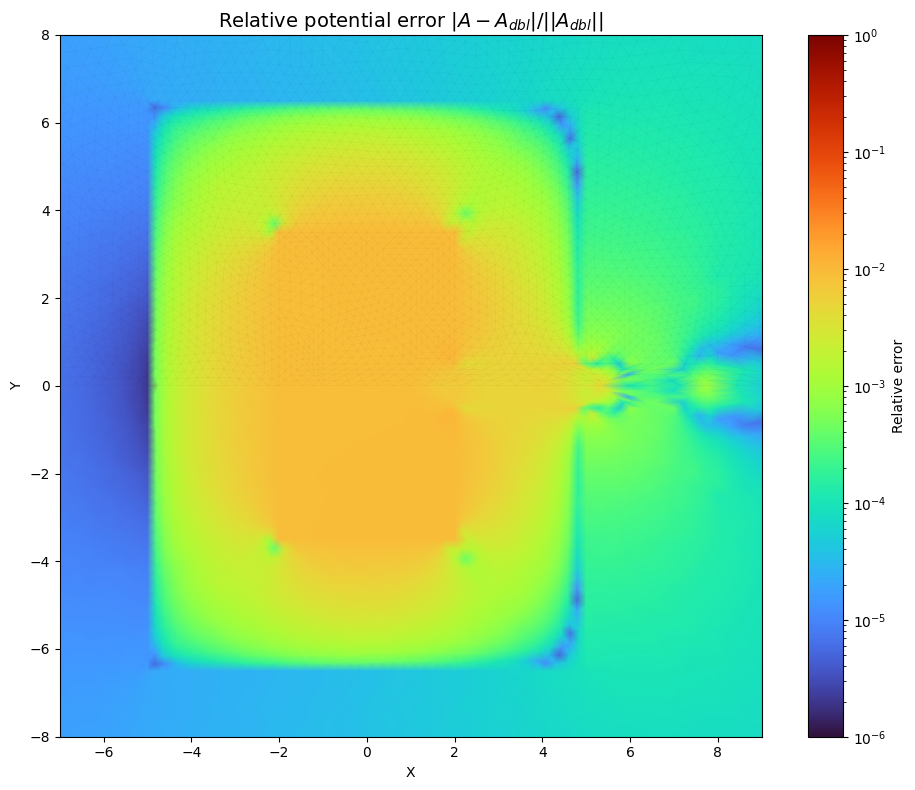

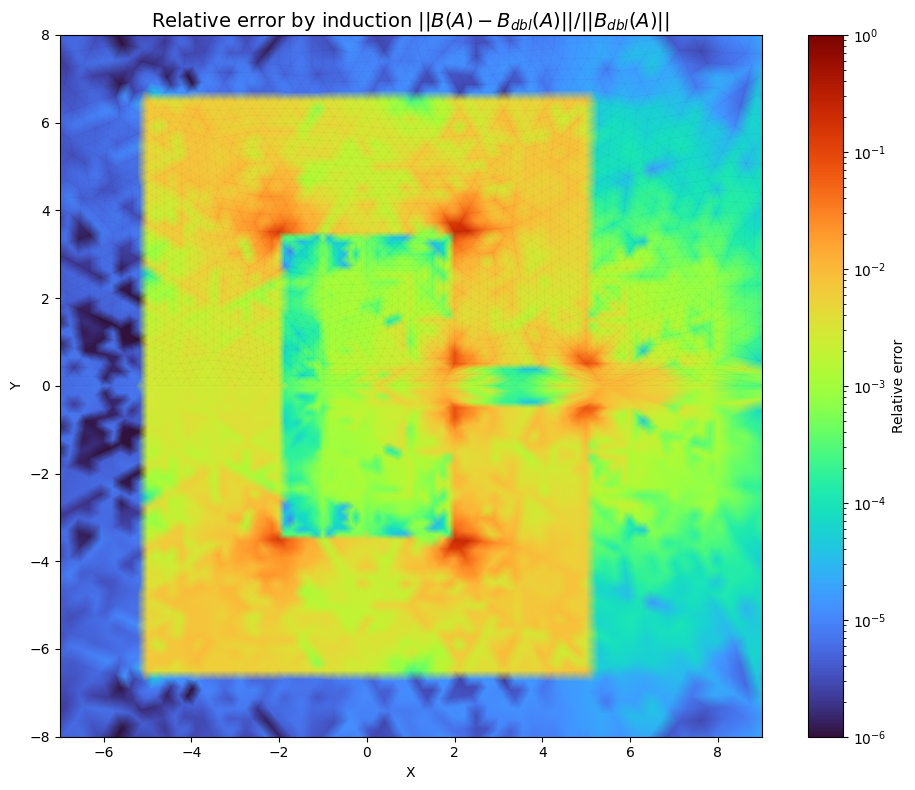

In [34]:
def plot_error_field(error_values, title_text):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_aspect('equal')
    ax.set_xlim(-7, 9)
    ax.set_ylim(-8, 8)
    ax.set_title(title_text, fontsize=14)

    norm = colors.LogNorm(vmin=1e-6, vmax=1)

    p_top = ax.tripcolor(triang_c_top, error_values, norm=norm, shading='gouraud', cmap='turbo')
    p_bottom = ax.tripcolor(triang_c_bottom, error_values, norm=norm, shading='gouraud', cmap='turbo')

    ax.triplot(triang_c_top, color='black', alpha=0.05, linewidth=0.3)

    fig.colorbar(p_top, ax=ax, label='Relative error')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.tight_layout()
    plt.show()

plot_error_field(error_A, r"Relative potential error $|A - A_{dbl}| / ||A_{dbl}||$")
plot_error_field(error_B, r"Relative error by induction $||B(A) - B_{dbl}(A)|| / ||B_{dbl}(A)||$")